In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\Student-performance\Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [4]:
l = ["Hours Studied", "Sleep Hours", "Sample Question Papers Practiced"]
for i in l:
    print(i,":",df[i].unique())
    print("-"*50)

Hours Studied : [7 4 8 5 3 6 2 1 9]
--------------------------------------------------
Sleep Hours : [9 4 7 5 8 6]
--------------------------------------------------
Sample Question Papers Practiced : [1 2 5 6 0 8 3 4 9 7]
--------------------------------------------------


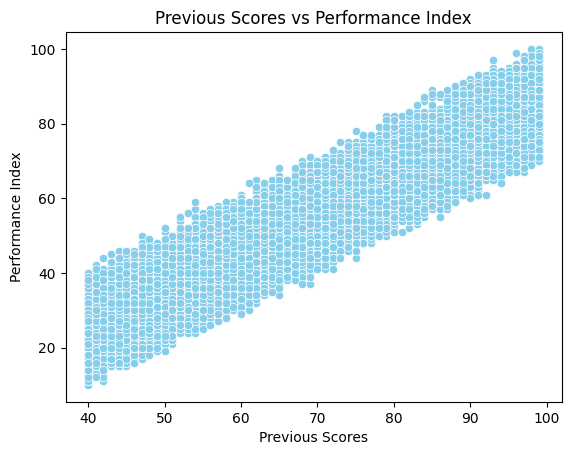

In [5]:
sns.scatterplot(x="Previous Scores",y="Performance Index",color="skyblue",data=df)
plt.title("Previous Scores vs Performance Index")
plt.show()

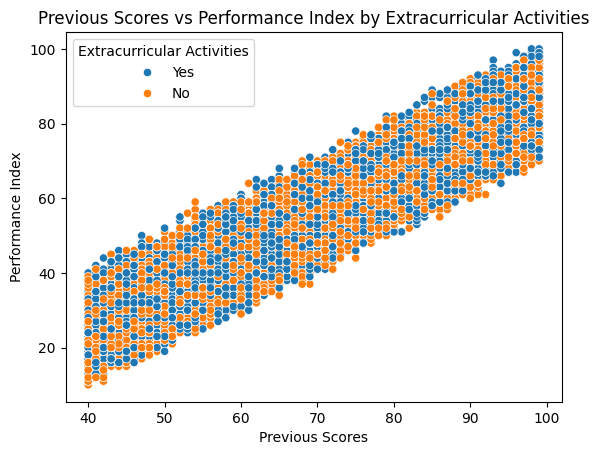

In [6]:
sns.scatterplot(x="Previous Scores",y="Performance Index",hue="Extracurricular Activities",color="skyblue",data=df)
plt.title("Previous Scores vs Performance Index by Extracurricular Activities")
plt.show()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64


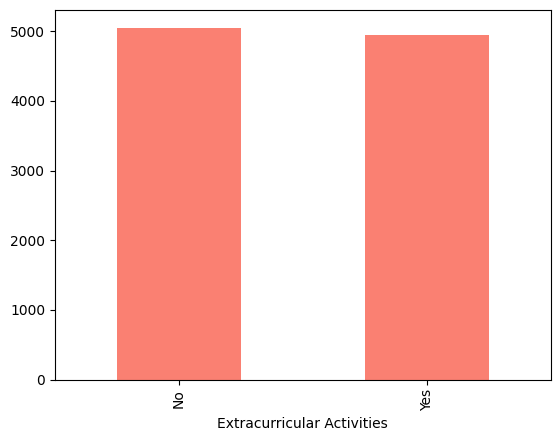

In [7]:
print(df["Extracurricular Activities"].value_counts())
df["Extracurricular Activities"].value_counts().plot(kind="bar",color="salmon")
plt.show()

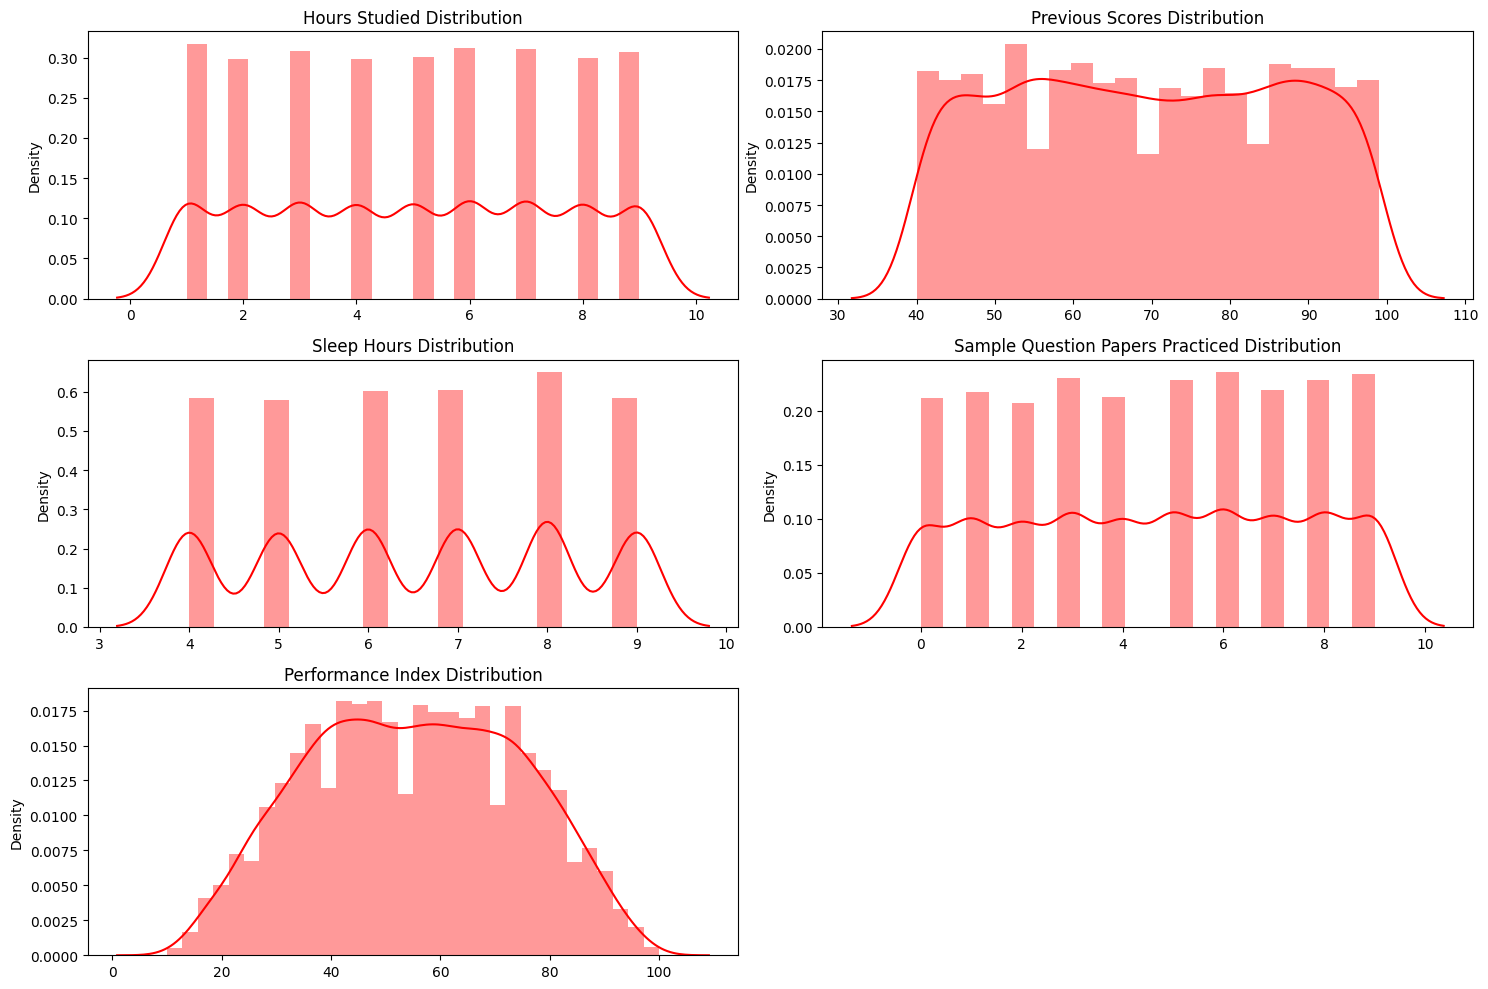

In [8]:
plt.figure(figsize=(15,10))
for i,col in enumerate(["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced","Performance Index"]):
    plt.subplot(3,2,i+1)   #3 rows, 2 columns, current plot number
    sns.distplot(df[col],color="red")
    plt.title(f"{col} Distribution")
    plt.xlabel("")
plt.tight_layout() #adjusts spacing between subplots
plt.show()

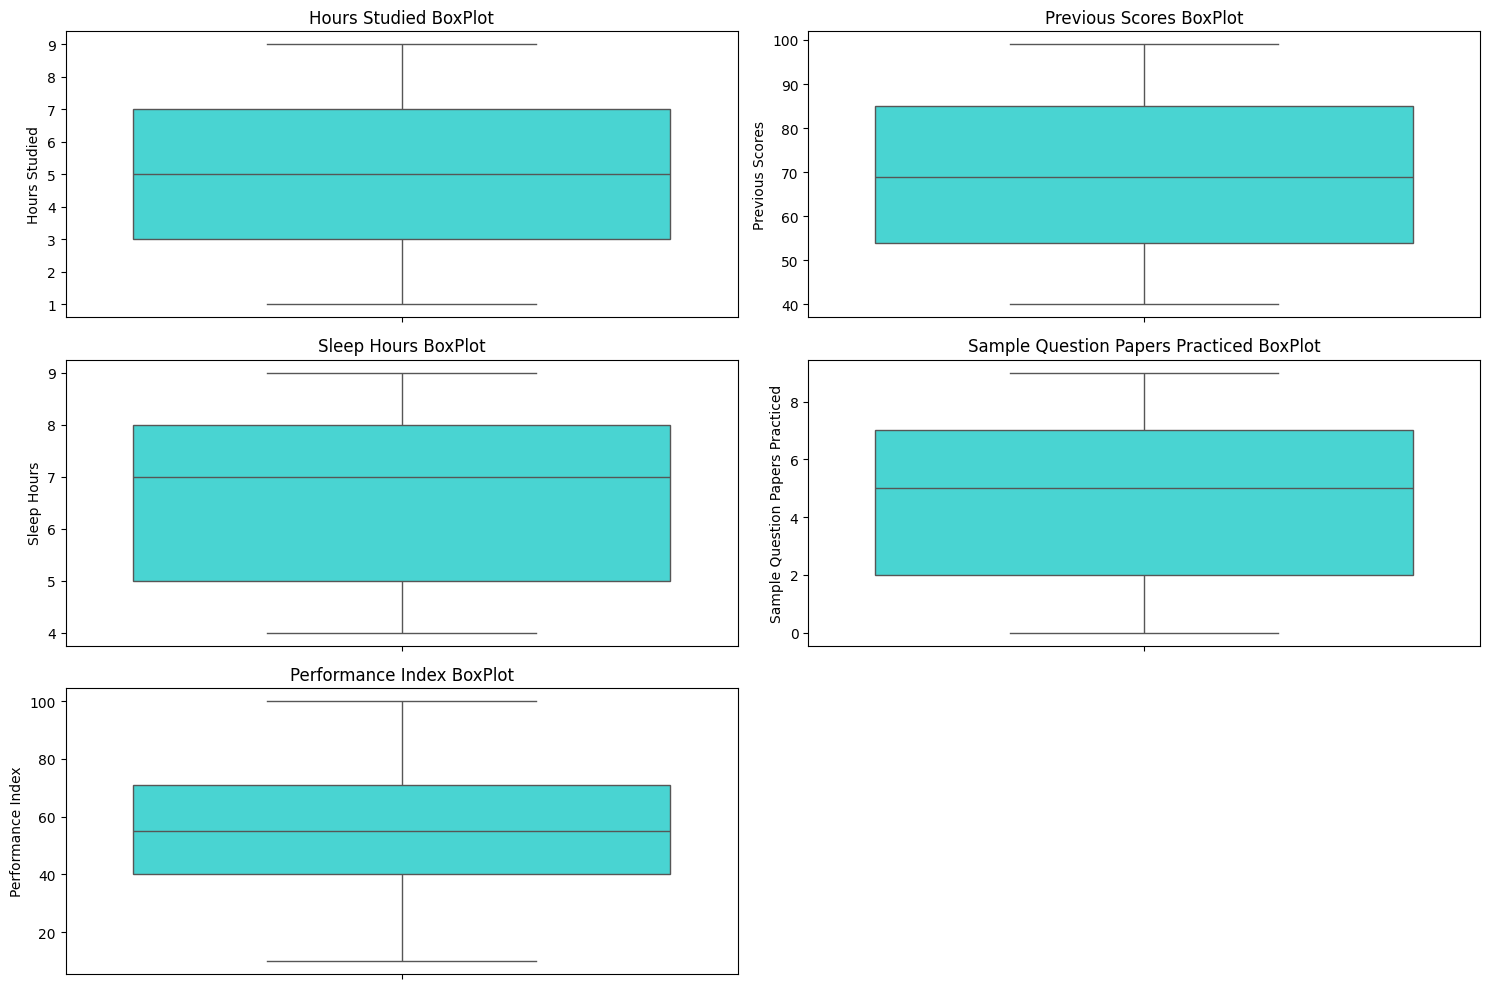

In [9]:
plt.figure(figsize=(15,10))
for i,col in enumerate(["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced","Performance Index"]):
    plt.subplot(3,2,i+1)
    sns.boxplot(df[col],color="#32EBE9")
    plt.title(f"{col} BoxPlot")
    plt.xlabel("")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

x = df.drop("Performance Index",axis=1)
y = df["Performance Index"]

#test size is 25% of data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)
print((f"x train shape: {x_train.shape}"))
print((f"x test shape: {x_test.shape}"))


x train shape: (7500, 5)
x test shape: (2500, 5)


In [11]:
x_train["Extracurricular Activities"] = x_train["Extracurricular Activities"].map({"Yes":1,"No":0},inplace=True)
x_test["Extracurricular Activities"] = x_test["Extracurricular Activities"].map({"Yes":1,"No":0},inplace=True)
print(x_train["Extracurricular Activities"].unique())
print(x_test["Extracurricular Activities"].unique())

[0 1]
[0 1]


In [12]:
x_train.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
4901,5,49,0,5,5
4375,7,88,1,4,9
6698,3,94,1,7,1
9805,9,54,1,5,9
1101,4,56,1,8,6


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #makes mean 0 and std deviation 1
cols_for_scaler = ["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced"]
x_train[cols_for_scaler] = scaler.fit_transform(x_train[cols_for_scaler])
x_test[cols_for_scaler] = scaler.transform(x_test[cols_for_scaler])

In [14]:
x_train.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
count,7.500000e+03,7.500000e+03,7500.000000,7.500000e+03,7.500000e+03
mean,1.477929e-16,3.060071e-16,0.494533,2.216893e-16,-4.926430e-17
std,1.000067e+00,1.000067e+00,0.500003,1.000067e+00,1.000067e+00
min,-1.533210e+00,-1.709770e+00,0.000000,-1.497318e+00,-1.614457e+00
25%,-7.626235e-01,-8.445213e-01,0.000000,-9.087495e-01,-9.154169e-01
50%,7.962724e-03,2.072752e-02,0.000000,2.683871e-01,1.331439e-01
75%,7.785489e-01,8.859764e-01,1.000000,8.569554e-01,8.321844e-01
max,1.549135e+00,1.693542e+00,1.000000,1.445524e+00,1.531225e+00


In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
def calculate_model_metrics(true, predicted):
    mae = mean_absolute_error(true, predicted) #average of absolute differences between true and predicted values
    mse = mean_squared_error(true, predicted) #average of squared differences between true and predicted values
    rmse = np.sqrt(mean_squared_error(true, predicted)) #square root of mean squared error, gives error in same units as target variable
    r2_square = r2_score(true, predicted) #proportion of variance in target variable explained by model, ranges from 0 to 1 (higher is better)
    return mae, rmse, r2_square

In [24]:
model = LinearRegression()


In [25]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)


[54.73187888 22.61211054 47.90838844 ... 68.07396952 53.68636805
 54.85816372]


In [28]:
model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)


print("RMSE :", model_test_rmse)
print("Mean Absolute Error :", model_test_mae)
print("R2 Score :", model_test_r2)


RMSE : 2.008119571992445
Mean Absolute Error : 1.5975792091646117
R2 Score : 0.9890550757439104


In [30]:
import joblib
joblib.dump(model, "student_performance_model.pkl")

['student_performance_model.pkl']